# 3 — A real pipeline: NISAR granules to a multi-sensor snow time series

[`1_test_virtualizarr.ipynb`](1_test_virtualizarr.ipynb) asked whether VirtualiZarr works on
NISAR at all. [`2_cube_maintenance.ipynb`](2_cube_maintenance.ipynb) asked whether we can operate
it. This notebook runs the whole lifecycle and then uses the result for a real question.

1. **Create** — search the archive, build chunk manifests, group by output grid, commit an
   Icechunk store.
2. **Round-trip** — read pixels back out of the virtual cube and prove they are byte-identical to
   the source HDF5.
3. **Use** — L-band backscatter at the **Paradise SNOTEL station** on Mount Rainier, beside
   coincident Sentinel-1 C-band, Sentinel-2 optical, and the station's own snow-water-equivalent
   record.
4. **Maintain** — a new acquisition is published; append it.

The structure follows VirtualiZarr's
[`its_live.ipynb`](https://github.com/zarr-developers/VirtualiZarr/blob/main/examples/V2/its_live.ipynb)
example — virtual references in, Icechunk store, real pixels back out — and the study area and
geometries follow
[`nisar/notebooks/mt_rainier_GCOV_backscatter_time_series.ipynb`](../../../nisar/notebooks/mt_rainier_GCOV_backscatter_time_series.ipynb),
so the two can be compared directly. The difference is the access path: that notebook opens 28
HDF5 files over HTTPS every session; this one opens one Icechunk store.

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd
import rioxarray  # noqa: F401 - registers .rio
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import icechunk
import nisar_virtual as nv

icechunk.set_logs_filter("error")
nv.earthaccess.login(strategy="netrc")

EPSG = 32610                       # the NISAR output grid's CRS
REPO_PATH = Path.home() / "nisar_cubes" / "rainier_gcov"
REPO_PATH.parent.mkdir(parents=True, exist_ok=True)
GEOM = Path("/home/jovyan/repos/nisar/geometries")

# --- chart styling -----------------------------------------------------------
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]      # co-pol / cross-pol / ground truth
# validated 8-slot categorical order: NISAR tracks take slots 1-3 (bold dots),
# Sentinel-1 orbits take 4-7 (lighter lines), so identity is never colour-alone.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SAR_CMAP = "Greys_r"                          # SAR amplitude convention
SAR_VMIN, SAR_VMAX = -18.0, 2.0               # dB, shared by every SAR panel
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": "#d8d7d2",
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#ecebe7", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 120,
    "legend.frameon": False,
})
print("ready")

ready


---
## 1. Create

### 1.1 Study area

The wide search box is **centred on the summit** (46.8523 N, 121.7603 W) so the cube is
symmetric about the edifice rather than offset from it. The analysis AOIs are the two small
Paradise fields either side of the SNOTEL station, ~9 km south of the summit.

In [2]:
SUMMIT = (-121.7603, 46.8523)
HALF_LON, HALF_LAT = 0.1807, 0.1050
BBOX = (SUMMIT[0] - HALF_LON, SUMMIT[1] - HALF_LAT,
        SUMMIT[0] + HALF_LON, SUMMIT[1] + HALF_LAT)

field_gdf  = gpd.read_file(GEOM / "paradise_road_loop_snow_field.geojson")
north_gdf  = gpd.read_file(GEOM / "snotel_field_north.geojson")
south_gdf  = gpd.read_file(GEOM / "snotel_field_south.geojson")
snotel_gdf = gpd.read_file(GEOM / "paradise_snotel.geojson")
# the SNOTEL geojson is a small polygon around the station; the star wants a point
snotel_pt = snotel_gdf.copy()
snotel_pt["geometry"] = snotel_gdf.geometry.centroid

def local(ts):
    return pd.Timestamp(ts).tz_localize("UTC").tz_convert("US/Pacific")

def orbit_label(relorb, direction, times, sensor):
    t = local(pd.DatetimeIndex(times)[len(times) // 2])
    d = {"A": "asc", "D": "desc", "ascending": "asc", "descending": "desc"}.get(direction, direction)
    return f"{sensor} {relorb} {d} · {t:%H:%M} {t.tzname()}"

print(f"search bbox   : {tuple(round(v, 4) for v in BBOX)}")
print(f"  centre      : ({(BBOX[0]+BBOX[2])/2:.4f}, {(BBOX[1]+BBOX[3])/2:.4f})")
print(f"  summit      : ({SUMMIT[0]:.4f}, {SUMMIT[1]:.4f})  <- centred\n")
for name, g in (("paradise field", field_gdf), ("north field", north_gdf),
                ("south field", south_gdf), ("snotel", snotel_gdf)):
    print(f"{name:15s} {g.total_bounds.round(4)}")

search bbox   : (-121.941, 46.7473, -121.5796, 46.9573)
  centre      : (-121.7603, 46.8523)
  summit      : (-121.7603, 46.8523)  <- centred

paradise field  [-121.7517   46.7806 -121.7442   46.7855]
north field     [-121.7489   46.7841 -121.7475   46.785 ]
south field     [-121.7471   46.7824 -121.7457   46.7835]
snotel          [-121.7514   46.7819 -121.7485   46.7838]


### 1.2 Find the granules

`nv.find_track` groups CMR results by orbit direction, relative orbit, frame and polarization, and
keeps **one granule per acquisition** — the archive holds more than one product version of some
takes, and indexing both would silently put the same date into the cube twice.

In [3]:
t0 = time.time()
tracks = nv.find_track(BBOX)
print(f"search: {time.time() - t0:.1f}s\n")
for (direction, relorb, frame, pols), its in tracks.items():
    print(f"  {direction} orbit {relorb} frame {frame} {pols}: "
          f"{len(its):3d} granules  {its[0][0][:8]} .. {its[-1][0][:8]}")

key, items = next(iter(tracks.items()))
print(f"\nusing the longest series: {key}")

search: 0.5s

  D orbit 065 frame 4005 DHDH:  28 granules  20251110 .. 20260818
  A orbit 025 frame 4005 DHDH:   9 granules  20260621 .. 20260820
  A orbit 026 frame 4005 DHDH:   3 granules  20260708 .. 20260813

using the longest series: ('D', '065', '4005', 'DHDH')


### 1.3 Build the chunk manifests

The only expensive step, and it happens once. `drop_variables` keeps the two polarizations plus
coordinates and discards the nine per-granule masks and scalars, which roughly halves the build
and cuts the reference count threefold. The process pool is worth ~1.4× on its own but is close to
a wash at 28 granules, because each of the eight workers pays for its own Earthdata login; it
starts paying once the archive is a few hundred granules deep.

In [4]:
probe = nv.build_manifests([items[0][1]])[0]
drop = nv.drop_outside(list(probe.variables))
print(f"keeping  {[v for v in probe.variables if v not in drop]}")
print(f"dropping {len(drop)}: {drop}\n")

t0 = time.time()
vdss = nv.build_manifests([u for _, u in items], drop_variables=drop, workers=8)
dt = time.time() - t0
refs = sum(int(np.prod(v[p].data.manifest.shape_chunk_grid))
           for v in vdss for p in ("HHHH", "HVHV"))
print(f"{len(vdss)} manifests in {dt:.1f}s ({dt/len(vdss):.2f}s each), "
      f"{refs:,} chunk references")

keeping  ['xCoordinates', 'yCoordinates', 'HHHH', 'HVHV', 'projection']
dropping 9: ['inputDataExceptionMask', 'listOfCovarianceTerms', 'listOfPolarizations', 'mask', 'numberOfLooks', 'numberOfSubSwaths', 'rtcGammaToSigmaFactor', 'xCoordinateSpacing', 'yCoordinateSpacing']



28 manifests in 12.3s (0.44s each), 277,620 chunk references


### 1.4 Group by output grid

**Not optional.** Granules sharing a track and frame can still be posted to different output
grids. `nv.grid_signature` keys on the shape and origin of the coordinate arrays — the thing that
actually decides whether two granules can be stacked.

In [5]:
grids = nv.group_by_grid(items, vdss)
for i, ((ny, nx, x0, y0), mem) in enumerate(grids.items()):
    print(f"grid {i}: {ny} x {nx} at ({x0:.0f}, {y0:.0f})  {len(mem)} granules "
          f"({mem[0][0][:8]} .. {mem[-1][0][:8]})")

members = sorted(next(iter(grids.values())))
print(f"\nkeeping the dominant grid: {len(members)} of {len(items)} granules")

grid 0: 35712 x 36144 at (334805, 5320075)  23 granules (20251110 .. 20260813)
grid 1: 35352 x 35784 at (496805, 5320795)  5 granules (20260619 .. 20260818)

keeping the dominant grid: 23 of 28 granules


The granules on the second grid are exactly those whose filename carries a different
relative-orbit field, and they are acquired about eight minutes earlier in the day. The filename
predicts the grid perfectly here — a useful smell test, but not a substitute for the check.
Filenames describe intent; coordinate arrays describe what was written.

In [6]:
from collections import Counter
for i, (sig, mem) in enumerate(grids.items()):
    print(f"grid {i}: relative-orbit field "
          f"{dict(Counter(u.rsplit('/', 1)[-1].split('_')[5] for _, u, _ in mem))}")

grid 0: relative-orbit field {'172': 23}
grid 1: relative-orbit field {'071': 5}


### 1.5 Commit

The most recent acquisition is held back so section 4 has something real to append.

In [7]:
import shutil
holdout, initial = members[-1], members[:-1]
print(f"indexing {len(initial)} granules, holding back {holdout[0][:8]}\n")

if REPO_PATH.exists():
    shutil.rmtree(REPO_PATH)
repo = nv.open_repo(REPO_PATH, create=True)

cube_v = nv.concat_cube(initial)
session = repo.writable_session("main")
t0 = time.time()
cube_v.vz.to_icechunk(session.store)
snap = session.commit(f"initial cube: {len(initial)} acquisitions")
print(f"committed {snap} in {time.time() - t0:.1f}s")

logical = sum(np.prod(cube_v[p].shape) * 4 for p in ("HHHH", "HVHV"))
index = sum(f.stat().st_size for f in REPO_PATH.rglob("*") if f.is_file())
print(f"\nlogical data indexed : {logical / 1e12:.2f} TB")
print(f"index on disk        : {index / 1e6:.1f} MB   ({logical / index:,.0f}x)")

indexing 22 granules, holding back 20260813



committed K5TSAXG2HPQGENN2G99G in 0.8s

logical data indexed : 0.23 TB
index on disk        : 4.7 MB   (48,337x)


---
## 2. Round-trip

Virtual references went in; real pixels come out. Nothing was copied to make that true, so it is
worth proving rather than asserting: read a window from the reopened cube and compare it against
the same window read directly from the source `.h5` with `h5py`.

In [8]:
t0 = time.time()
cube = nv.open_cube(repo)
print(f"reopened from Icechunk in {time.time() - t0:.2f}s\n")
print(cube)

reopened from Icechunk in 0.07s

<xarray.Dataset> Size: 227GB
Dimensions:       (time: 22, yCoordinates: 35712, xCoordinates: 36144)
Coordinates:
  * time          (time) datetime64[ns] 176B 2025-11-10T03:18:48 ... 2026-07-...
  * yCoordinates  (yCoordinates) float64 286kB 5.32e+06 5.32e+06 ... 4.963e+06
  * xCoordinates  (xCoordinates) float64 289kB 3.348e+05 3.348e+05 ... 6.962e+05
Data variables:
    HHHH          (time, yCoordinates, xCoordinates) float32 114GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    HVHV          (time, yCoordinates, xCoordinates) float32 114GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    projection    (time) uint32 88B dask.array<chunksize=(1,), meta=np.ndarray>


In [9]:
import h5py
from obspec_utils.readers import BlockStoreReader

registry = nv.obstore_registry()
s_check, u_check, _ = initial[len(initial) // 2]
win = dict(yCoordinates=slice(13750, 13850), xCoordinates=slice(26120, 26220))

store, path = registry.resolve(u_check)
with h5py.File(BlockStoreReader(store, path), "r") as f:
    truth = f[f"{nv.GCOV_GRIDS}/HHHH"][13750:13850, 26120:26220]

got = cube.HHHH.sel(time=pd.to_datetime(s_check, format="%Y%m%dT%H%M%S")).isel(**win).values

print(f"granule        : {u_check.rsplit('/', 1)[-1][:58]}...")
print(f"window         : {truth.shape}, fill fraction {np.isnan(truth).mean():.2f}")
print(f"mean γ⁰        : direct {np.nanmean(truth):.6f} | cube {np.nanmean(got):.6f}")
print(f"byte-identical : {np.array_equal(truth, got, equal_nan=True)}")

granule        : NISAR_L2_PR_GCOV_015_172_D_065_4005_DHDH_A_20260322T031853...
window         : (100, 100), fill fraction 0.00
mean γ⁰        : direct 0.185701 | cube 0.185701
byte-identical : True


---
## 3. Paradise SNOTEL

### 3.1 Clipping the cube to a 600 m field

The cube covers a 357 km frame; the AOI is a snow field a few hundred metres across. Subset by
index first, then hand the result to `rioxarray` for geometry-aware clipping.

In [10]:
# Index-subset the full-frame cube to a small AOI, then attach the CRS so
# rioxarray can do geometry-aware clipping on it.
def chip(da, gdf, buffer=200):
    minx, miny, maxx, maxy = gdf.to_crs(EPSG).total_bounds
    x, y = da.xCoordinates.values, da.yCoordinates.values
    xs = np.where((x >= minx - buffer) & (x <= maxx + buffer))[0]
    ys = np.where((y >= miny - buffer) & (y <= maxy + buffer))[0]
    out = da.isel(xCoordinates=slice(xs[0], xs[-1] + 1),
                  yCoordinates=slice(ys[0], ys[-1] + 1))
    return (out.rename(xCoordinates="x", yCoordinates="y")
               .rio.write_crs(EPSG))

def to_db(da):
    return 10 * np.log10(da.where(da > 0))

def retry(fn, n=4, wait=4):
    # A cube read is hundreds of range requests against a busy bucket, and S3
    # returns the occasional InternalError or dropped connection. Retry rather
    # than lose a long notebook run to one bad response.
    for attempt in range(n):
        try:
            return fn()
        except Exception as exc:
            if attempt == n - 1:
                raise
            print(f"  transient {type(exc).__name__}, retry {attempt + 1}/{n - 1}")
            time.sleep(wait)

t0 = time.time()
nisar_hh = retry(lambda: to_db(chip(cube.HHHH, field_gdf)).compute())
nisar_hv = retry(lambda: to_db(chip(cube.HVHV, field_gdf)).compute())
print(f"clipped and read in {time.time() - t0:.1f}s")
print(f"chip: {dict(nisar_hh.sizes)}  "
      f"({nisar_hh.sizes['x'] * 10} m x {nisar_hh.sizes['y'] * 10} m at 10 m posting)")

clipped and read in 1.6s
chip: {'time': 22, 'y': 96, 'x': 98}  (980 m x 960 m at 10 m posting)


### 3.2 The SAR image time series

Grayscale is the convention for SAR amplitude, and it is not merely a habit — speckle is
multiplicative noise that a hue ramp turns into false colour structure. Every SAR panel in this
notebook shares one grayscale ramp and one dB range so the panels are comparable to each other,
with the colourbar carried alongside.

North field in green, south field in purple, the SNOTEL station itself as a red star.

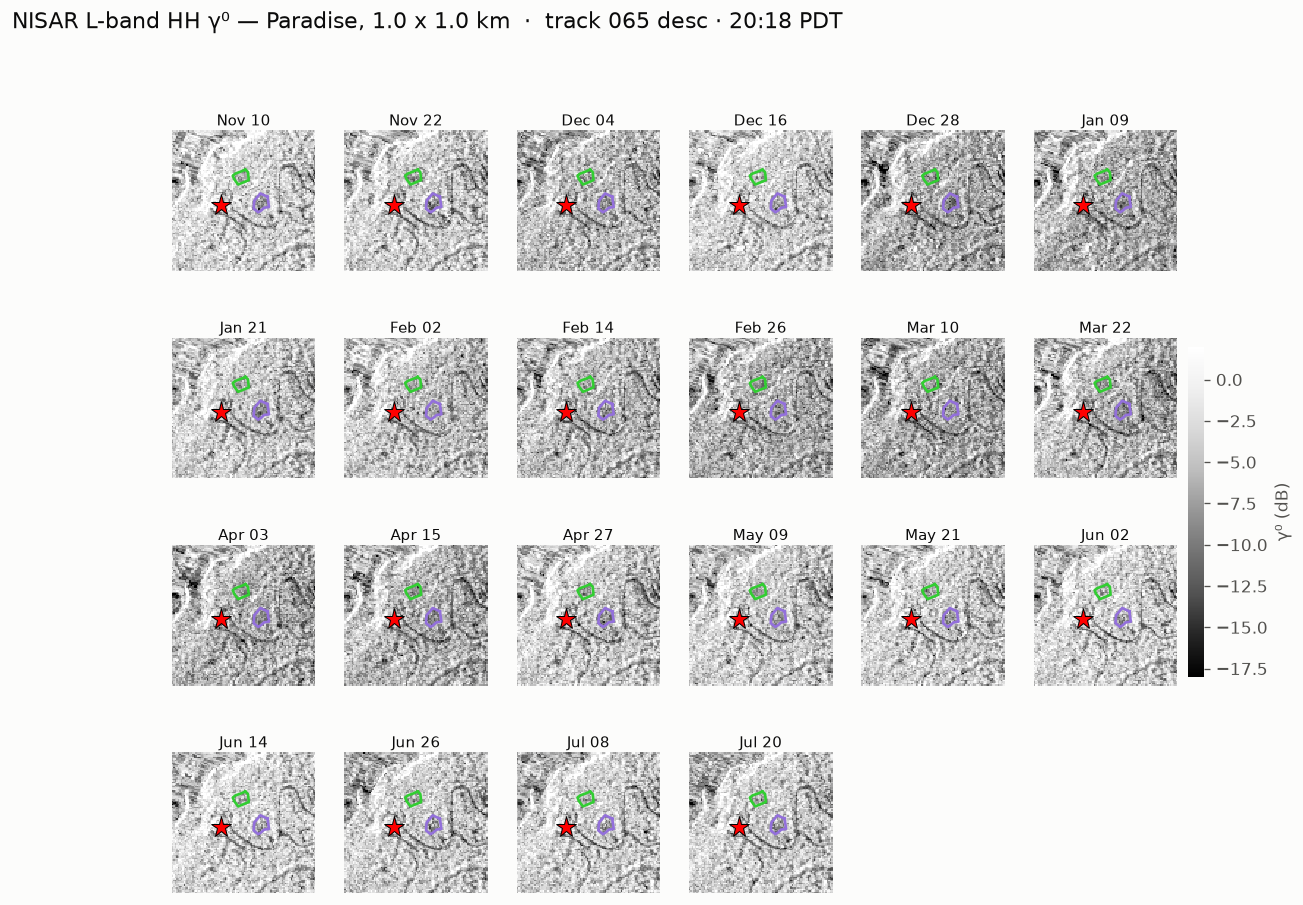

In [11]:
def overlay(ax, gdf, color, lw=2.0, marker=None):
    g = gdf.to_crs(EPSG)
    for geom in g.geometry:
        if geom.geom_type == "Point":
            ax.plot(geom.x, geom.y, marker=marker or "*", color=color,
                    markersize=13, markeredgecolor="black", markeredgewidth=0.6)
        else:
            xs, ys = geom.exterior.xy
            ax.plot(xs, ys, color=color, lw=lw)

def sar_grid(da, title, ncols=6):
    n = da.sizes["time"]
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.85 * ncols, 2.15 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i in range(len(axes)):
        ax = axes[i]
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        if i >= n:
            ax.set_visible(False); continue
        sc = da.isel(time=i)
        im = ax.pcolormesh(sc.x.values, sc.y.values, sc.values, cmap=SAR_CMAP,
                           vmin=SAR_VMIN, vmax=SAR_VMAX, shading="nearest")
        overlay(ax, north_gdf, "limegreen", 1.6)
        overlay(ax, south_gdf, "mediumpurple", 1.6)
        overlay(ax, snotel_pt, "red")
        ax.set_aspect("equal")
        ax.set_title(pd.Timestamp(sc.time.values).strftime("%b %d"),
                     fontsize=9, color=INK, pad=3)
    cb = fig.colorbar(im, ax=axes.tolist(), fraction=0.016, pad=0.01)
    cb.set_label("γ⁰ (dB)", color=INK2); cb.outline.set_visible(False)
    fig.suptitle(title, x=0.005, ha="left", fontsize=13, color=INK)
    return fig

TRACK = f"{key[0]} {key[1]}"     # e.g. "D 065"
sar_grid(nisar_hh, f"NISAR L-band HH γ⁰ — Paradise, "
                  f"{nisar_hh.sizes['x'] * 10 / 1000:.1f} x "
                  f"{nisar_hh.sizes['y'] * 10 / 1000:.1f} km  ·  "
                  f"{orbit_label(key[1], key[0], nisar_hh.time.values, 'track')}")
plt.show()

### 3.3 Field medians

**Median, not mean.** SAR backscatter is speckle-dominated and its distribution over a small
window is skewed; the median is the robust estimator and it is what the reference notebook uses,
so the two are comparable.

In [12]:
def field_median(da, gdf):
    # log10 arithmetic drops the CRS that `chip` attached, so re-assert it
    # before asking rioxarray to clip by geometry.
    clipped = (da.rio.write_crs(EPSG)
                 .rio.clip(gdf.to_crs(EPSG).geometry, all_touched=True))
    return clipped.median(dim=("x", "y"), skipna=True).to_series()

nisar = pd.DataFrame({
    ("north", "HH"): field_median(nisar_hh, north_gdf),
    ("north", "HV"): field_median(nisar_hv, north_gdf),
    ("south", "HH"): field_median(nisar_hh, south_gdf),
    ("south", "HV"): field_median(nisar_hv, south_gdf),
})
nisar.columns = pd.MultiIndex.from_tuples(nisar.columns, names=["field", "pol"])
print(nisar.round(2).to_string())

field               north        south           
pol                    HH     HV    HH         HV
time                                             
2025-11-10 03:18:48 -5.63 -12.21 -7.34 -13.650000
2025-11-22 03:18:48 -6.80 -12.94 -8.15 -14.640000
2025-12-04 03:18:49 -6.69 -12.27 -8.03 -15.200000
2025-12-16 03:18:49 -5.47 -11.58 -6.61 -13.610000
2025-12-28 03:18:50 -7.72 -15.29 -9.47 -17.290001
2026-01-09 03:18:50 -8.05 -14.03 -9.17 -16.430000
2026-01-21 03:18:51 -6.73 -13.44 -8.87 -14.790000
2026-02-02 03:18:52 -6.30 -12.77 -7.24 -14.210000
2026-02-14 03:18:52 -6.53 -13.52 -8.01 -15.790000
2026-02-26 03:18:53 -7.41 -13.61 -8.41 -15.600000
2026-03-10 03:18:53 -6.99 -14.02 -8.28 -14.790000
2026-03-22 03:18:53 -8.23 -15.09 -9.24 -16.370001
2026-04-03 03:18:54 -7.44 -14.22 -8.85 -16.379999
2026-04-15 03:18:54 -8.02 -14.83 -9.58 -16.080000
2026-04-27 03:18:54 -7.58 -13.09 -8.90 -14.850000
2026-05-09 03:18:53 -6.62 -12.76 -7.93 -14.410000
2026-05-21 03:18:53 -6.73 -12.58 -7.45 -14.220000


### 3.4 The other two tracks

A cube is one output grid, so it is also **one relative orbit**. The search returned three tracks
over Rainier and they are genuinely different observations — the descending track images in the
evening, the two ascending tracks just after dawn, when a spring snowpack has refrozen overnight.
Comparing them without saying which is which would be a mistake.

So: one cube per track. This is the data model asserting itself again, and it is the right answer
rather than a workaround — these grids cannot be stacked, and their acquisition geometries should
not be pooled.

In [13]:
def build_track(tkey, tracks, tag):
    its = tracks[tkey]
    vs = nv.build_manifests([u for _, u in its], drop_variables=drop, workers=8)
    mem = sorted(next(iter(nv.group_by_grid(its, vs).values())))
    path = REPO_PATH.parent / f"rainier_gcov_{tag}"
    if path.exists():
        shutil.rmtree(path)
    r = nv.open_repo(path, create=True)
    sess = r.writable_session("main")
    nv.concat_cube(mem).vz.to_icechunk(sess.store)
    sess.commit(f"{tkey} cube: {len(mem)} acquisitions")
    return r, len(mem), len(its)

CUBES = {key: (repo, cube)}
for tkey in list(tracks)[1:]:
    t0 = time.time()
    r, nkept, ntot = build_track(tkey, tracks, f"{tkey[0]}{tkey[1]}")
    c = nv.open_cube(r)
    CUBES[tkey] = (r, c)
    print(f"{tkey[0]} {tkey[1]}: {nkept}/{ntot} granules on the dominant grid, "
          f"{time.time() - t0:.1f}s  ·  "
          f"{orbit_label(tkey[1], tkey[0], c.time.values, 'track')}")

A 025: 5/9 granules on the dominant grid, 13.6s  ·  track 025 asc · 06:03 PDT


A 026: 3/3 granules on the dominant grid, 6.2s  ·  track 026 asc · 05:55 PDT


In [14]:
FIELDS = {"north": north_gdf, "south": south_gdf}

def track_medians(c):
    hh = retry(lambda: to_db(chip(c.HHHH, field_gdf)).compute())
    hv = retry(lambda: to_db(chip(c.HVHV, field_gdf)).compute())
    return {n: pd.DataFrame({"HH": field_median(hh, g), "HV": field_median(hv, g)})
            for n, g in FIELDS.items()}

t0 = time.time()
NISAR, EMPTY = {}, []
for tkey, (_, c) in CUBES.items():
    m = track_medians(c)
    # A grid can contain the AOI and still hold no data there: the output grid is
    # a rectangle, the imaged swath inside it is not.
    if m["north"].notna().to_numpy().any():
        NISAR[tkey] = m
    else:
        EMPTY.append(tkey)
print(f"{len(NISAR)} usable tracks x 2 fields x 2 pols in {time.time() - t0:.1f}s")
for tkey in EMPTY:
    print(f"  {tkey[0]} {tkey[1]}: grid contains Paradise but the pixels are fill "
          f"-> outside the imaged swath, dropped")
print()
for tkey, per_field in NISAR.items():
    d = per_field["north"]
    print(f"{tkey[0]} {tkey[1]}: {len(d):2d} dates  "
          f"{d.index[0]:%Y-%m-%d} .. {d.index[-1]:%Y-%m-%d}  "
          f"HH {d.HH.min():.1f} .. {d.HH.max():.1f} dB")

2 usable tracks x 2 fields x 2 pols in 4.8s
  A 026: grid contains Paradise but the pixels are fill -> outside the imaged swath, dropped

D 065: 22 dates  2025-11-10 .. 2026-07-20  HH -8.2 .. -4.9 dB
A 025:  5 dates  2026-06-21 .. 2026-08-20  HH -7.1 .. -5.7 dB


---
## 4. The same place, three sensors

A backscatter series on its own is hard to argue with because there is nothing to argue against.
Three independent records over the same field make it checkable:

- **Sentinel-1** — C-band, ~5.5 cm. Sensitive to the snow *surface* and to wet snow, and it
  saturates on shallower snow than L-band does.
- **Sentinel-2** — optical. Shows unambiguously whether there is snow on the ground, when it is
  not cloudy.
- **SNOTEL 679** — a pillow measuring snow water equivalent on the ground, between the two fields.

### 4.1 Sentinel-1 C-band

In [15]:
import easysnowdata

START, END = "2025-11-01", "2026-08-25"
t0 = time.time()
# request a padded footprint so the Sentinel-1 chips cover the same ground as
# the NISAR and Sentinel-2 panels they sit beside
field_pad = gpd.GeoDataFrame(
    geometry=field_gdf.to_crs(EPSG).buffer(220), crs=EPSG).to_crs(4326)
s1 = easysnowdata.remote_sensing.Sentinel1(bbox_input=field_pad,
                                           start_date=START, end_date=END)
s1_data = s1.data.compute()
print(f"\n{s1_data.sizes['time']} Sentinel-1 scenes in {time.time() - t0:.0f}s")

# Keep every relative orbit, but never pool them: each is a different look
# geometry and a different time of day, so each gets its own series.
S1_ORBITS = sorted(set(int(o) for o in s1_data["sat:relative_orbit"].values))
print(f"\n{len(S1_ORBITS)} Sentinel-1 relative orbits, kept separate:")
S1_META = {}
for o in S1_ORBITS:
    sub = s1_data.sel(time=s1_data["sat:relative_orbit"] == o)
    st = str(np.unique(sub["sat:orbit_state"].values)[0])
    S1_META[o] = (st, sub.time.values)
    print(f"  {orbit_label(o, st, sub.time.values, 'S1 orbit'):38s} {sub.sizes['time']:3d} scenes")
ORBIT = max(S1_META, key=lambda o: len(S1_META[o][1]))
s1_one = s1_data.sel(time=s1_data["sat:relative_orbit"] == ORBIT)

Data searched. Access the returned seach with the .search attribute.


Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.


Metadata retrieved. Access with the .metadata attribute.
Falsely low scenes and border noise removed from the data.
Added relative orbit number and orbit state as coordinates to the data.
Linear power units converted to dB. Convert back to linear power units using the .db_to_linear() method.



100 Sentinel-1 scenes in 33s

4 Sentinel-1 relative orbits, kept separate:
  S1 orbit 13 desc · 07:22 PDT            24 scenes
  S1 orbit 64 asc · 17:54 PST             35 scenes
  S1 orbit 115 desc · 07:13 PDT           23 scenes
  S1 orbit 137 asc · 19:01 PDT            18 scenes


In [16]:
s1_chip = s1_one.rio.write_crs(EPSG)      # the busiest orbit, for the image panels

t0 = time.time()
S1 = {}
for o in S1_ORBITS:
    sub = s1_data.sel(time=s1_data["sat:relative_orbit"] == o).rio.write_crs(EPSG)
    S1[o] = {n: pd.DataFrame({"VV": field_median(sub.vv, g),
                              "VH": field_median(sub.vh, g)})
             for n, g in FIELDS.items()}
print(f"{len(S1)} orbits x 2 fields x 2 pols in {time.time() - t0:.1f}s")

s1 = pd.DataFrame({("north", "VV"): S1[ORBIT]["north"].VV,
                   ("north", "VH"): S1[ORBIT]["north"].VH})
s1.columns = pd.MultiIndex.from_tuples(s1.columns, names=["field", "pol"])
print(f"busiest orbit {ORBIT}: {len(s1)} dates, "
      f"{s1.index[0]:%Y-%m-%d} .. {s1.index[-1]:%Y-%m-%d}")

4 orbits x 2 fields x 2 pols in 0.2s
busiest orbit 64: 35 dates, 2025-11-05 .. 2026-07-28


### 4.2 SNOTEL 679 — the ground truth

In [17]:
stations = easysnowdata.automatic_weather_stations.StationCollection()
stations.get_data("679_WA_SNTL")
snotel = stations.data.loc[START:END]
swe = snotel["WTEQ"]        # snow water equivalent, m
tavg = snotel["TAVG"]       # daily mean air temperature, C
print(f"{len(snotel)} daily records, {snotel.index[0].date()} .. {snotel.index[-1].date()}")
print(f"peak SWE {swe.max():.2f} m on {swe.idxmax():%Y-%m-%d}; "
      f"snow-free from {swe[swe.le(0.001)].index[swe[swe.le(0.001)].index > swe.idxmax()][0]:%Y-%m-%d}")

298 daily records, 2025-11-01 .. 2026-08-25
peak SWE 0.98 m on 2026-04-24; snow-free from 2026-06-15


### 4.3 Coincident optical imagery

For four NISAR dates spanning the season, the nearest low-cloud Sentinel-2 scene and the nearest
Sentinel-1 scene. "Coincident" is approximate — Sentinel-2 needs a clear sky and Rainier is
frequently not obliging — so each panel is labelled with its own date and the offset from the
NISAR acquisition.

In [18]:
from pystac_client import Client

targets = [pd.Timestamp(t) for t in
           ("2025-11-22", "2025-12-28", "2026-02-02", "2026-03-10",
            "2026-04-15", "2026-05-21", "2026-06-14", "2026-07-20")]
targets = [nisar.index[np.argmin(np.abs(nisar.index - t))] for t in targets]

cat = Client.open("https://earth-search.aws.element84.com/v1")
s2_items = list(cat.search(collections=["sentinel-2-l2a"],
                           bbox=list(field_gdf.total_bounds),
                           datetime=f"{START}/{END}",
                           query={"eo:cloud_cover": {"lt": 12}}).items())
s2_times = pd.DatetimeIndex([i.datetime.replace(tzinfo=None) for i in s2_items])
print(f"{len(s2_items)} low-cloud Sentinel-2 scenes available\n")

picks = []
for t in targets:
    j = int(np.argmin(np.abs(s2_times - t)))
    k = int(np.argmin(np.abs(s1.index - t)))
    picks.append({"nisar": t, "s2": s2_items[j], "s2_time": s2_times[j],
                  "s1_time": s1.index[k]})
    print(f"NISAR {t:%Y-%m-%d} | S2 {s2_times[j]:%Y-%m-%d} "
          f"({abs((s2_times[j]-t).days):+3d}d, cc={s2_items[j].properties['eo:cloud_cover']:.1f}%) "
          f"| S1 {s1.index[k]:%Y-%m-%d} ({abs((s1.index[k]-t).days):+3d}d)")

27 low-cloud Sentinel-2 scenes available

NISAR 2025-11-22 | S2 2025-11-30 ( +8d, cc=5.2%) | S1 2025-11-23 ( +0d)
NISAR 2025-12-28 | S2 2025-12-30 ( +2d, cc=9.4%) | S1 2025-12-29 ( +0d)
NISAR 2026-02-02 | S2 2026-01-24 ( +9d, cc=0.7%) | S1 2026-02-03 ( +0d)
NISAR 2026-03-10 | S2 2026-03-27 (+17d, cc=1.1%) | S1 2026-03-11 ( +0d)
NISAR 2026-04-15 | S2 2026-04-09 ( +6d, cc=0.0%) | S1 2026-04-16 ( +0d)
NISAR 2026-05-21 | S2 2026-05-11 (+10d, cc=3.0%) | S1 2026-05-22 ( +0d)
NISAR 2026-06-14 | S2 2026-06-13 ( +1d, cc=0.1%) | S1 2026-06-16 ( +1d)
NISAR 2026-07-20 | S2 2026-07-15 ( +5d, cc=2.7%) | S1 2026-07-16 ( +5d)


In [19]:
minx, miny, maxx, maxy = field_gdf.to_crs(EPSG).total_bounds
pad = 200

def s2_rgb(item):
    da = rioxarray.open_rasterio(item.assets["visual"].href, masked=False)
    if da.rio.crs.to_epsg() != EPSG:
        da = da.rio.reproject(f"EPSG:{EPSG}")
    return da.rio.clip_box(minx - pad, miny - pad, maxx + pad, maxy + pad)

t0 = time.time()
rgbs = [s2_rgb(p["s2"]) for p in picks]
print(f"{len(rgbs)} Sentinel-2 chips in {time.time() - t0:.1f}s, "
      f"{dict(rgbs[0].sizes)}")

8 Sentinel-2 chips in 7.3s, {'band': 3, 'y': 97, 'x': 99}


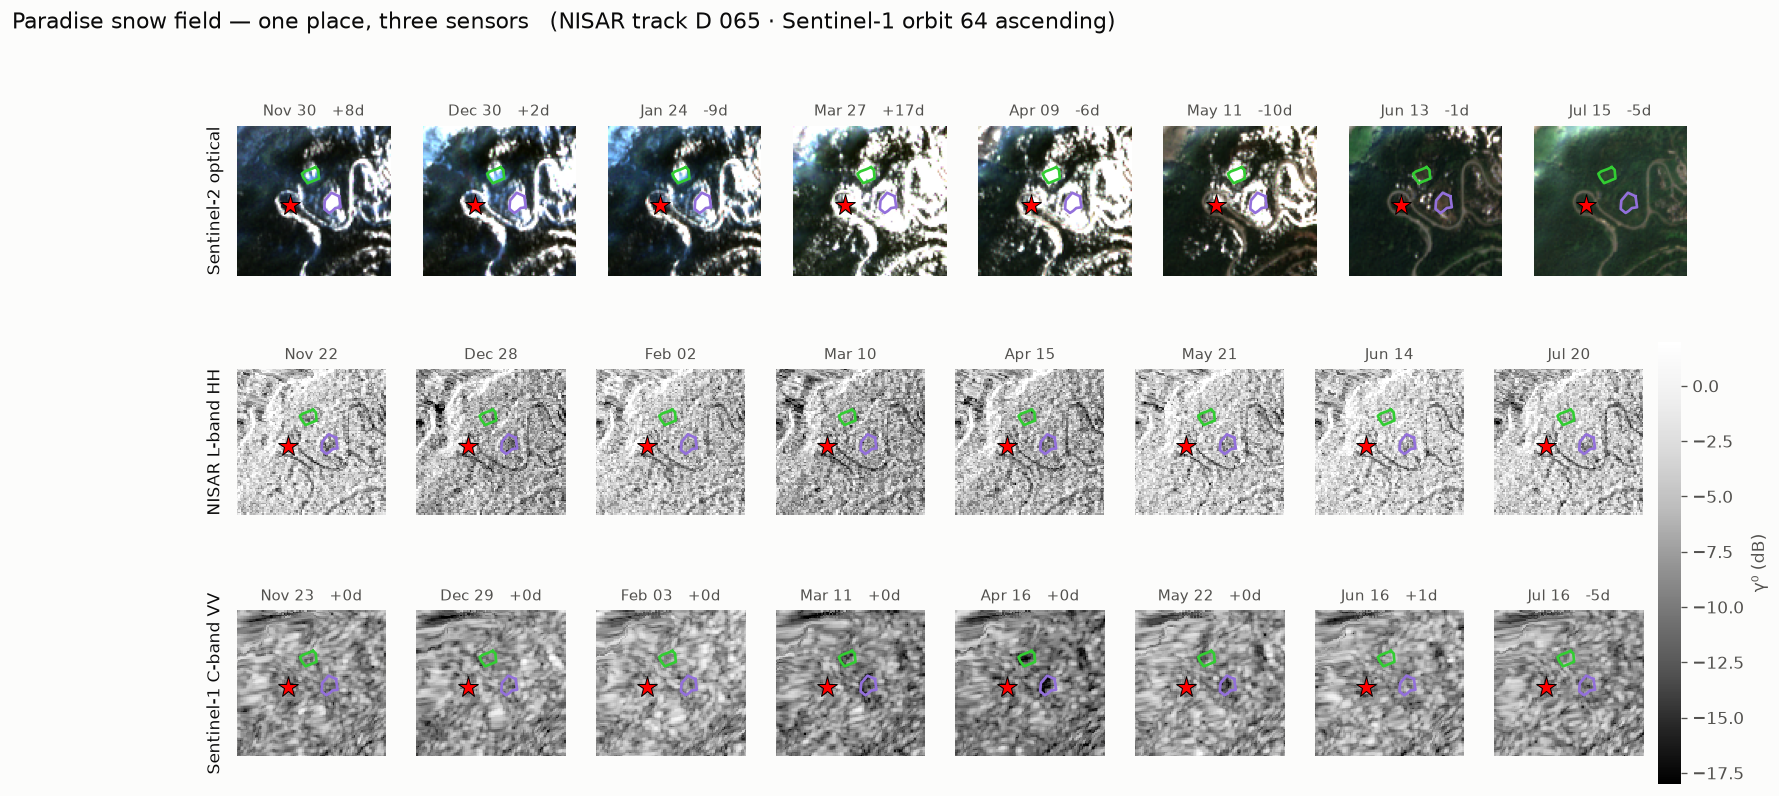

In [20]:
n = len(picks)
fig, axes = plt.subplots(3, n, figsize=(1.95 * n, 7.4))
ROWS = ["Sentinel-2 optical", "NISAR L-band HH", "Sentinel-1 C-band VV"]

for j, p in enumerate(picks):
    # --- optical -------------------------------------------------------------
    ax = axes[0, j]
    rgb = rgbs[j]
    ax.imshow(np.moveaxis(rgb.values[:3], 0, -1),
              extent=(float(rgb.x.min()), float(rgb.x.max()),
                      float(rgb.y.min()), float(rgb.y.max())))
    ax.set_title(f"{p['s2_time']:%b %d}   "
                 f"{(p['s2_time'] - p['nisar']).days:+d}d", fontsize=9, color=INK2)

    # --- NISAR ---------------------------------------------------------------
    ax = axes[1, j]
    sc = nisar_hh.sel(time=p["nisar"])
    im_n = ax.pcolormesh(sc.x.values, sc.y.values, sc.values, cmap=SAR_CMAP,
                         vmin=SAR_VMIN, vmax=SAR_VMAX, shading="nearest")
    ax.set_title(f"{p['nisar']:%b %d}", fontsize=9, color=INK2)

    # --- Sentinel-1 ----------------------------------------------------------
    ax = axes[2, j]
    sv = s1_chip.vv.sel(time=p["s1_time"])
    im_s = ax.pcolormesh(sv.x.values, sv.y.values, sv.values, cmap=SAR_CMAP,
                         vmin=SAR_VMIN, vmax=SAR_VMAX, shading="nearest")
    ax.set_title(f"{p['s1_time']:%b %d}   "
                 f"{(p['s1_time'] - p['nisar']).days:+d}d", fontsize=9, color=INK2)

    for i in range(3):
        a = axes[i, j]
        overlay(a, north_gdf, "limegreen", 1.6)
        overlay(a, south_gdf, "mediumpurple", 1.6)
        overlay(a, snotel_pt, "red")
        a.set_xlim(minx - pad, maxx + pad); a.set_ylim(miny - pad, maxy + pad)
        a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
        for s in a.spines.values():
            s.set_visible(False)

for i, lab in enumerate(ROWS):
    axes[i, 0].set_ylabel(lab, fontsize=10, color=INK, labelpad=8)

# both SAR rows share one scale, so they share one colourbar - and the rows
# keep the same height as the optical row instead of each being shrunk.
cb = fig.colorbar(im_n, ax=axes[1:, :].ravel().tolist(), fraction=0.020, pad=0.01)
cb.set_label("γ⁰ (dB)", color=INK2); cb.outline.set_visible(False)

fig.suptitle(f"Paradise snow field — one place, three sensors   "
             f"(NISAR track {key[0]} {key[1]} · Sentinel-1 orbit {ORBIT} "
             f"{S1_META[ORBIT][0]})",
             x=0.005, ha="left", fontsize=13, color=INK)
plt.show()

### 4.4 Orbit direction does not mean the same thing to both missions

Worth reading off the two listings above before plotting anything together:

| | ascending | descending |
|---|---|---|
| **NISAR** | ~06:00 local (dawn) | ~19:20 local (dusk) |
| **Sentinel-1** | ~18:00 local (dusk) | ~07:15 local (dawn) |

The labels are reversed between the two missions. Pairing "ascending with ascending" would pair a
dawn overpass with a dusk one — and for a spring snowpack that is the difference between refrozen
and wet, which is most of the signal. Pair on **local time**, not on the direction flag, and say
which orbit every series came from.

### 4.5 The time series

Four rows on a shared time axis: L-band, C-band, the snow pillow, and air temperature. Backscatter
panels are kept separate rather than sharing one frame — L-band and C-band are both dB but they
are different measurements, and stacking them in one axis would invite reading a difference that
is mostly wavelength.

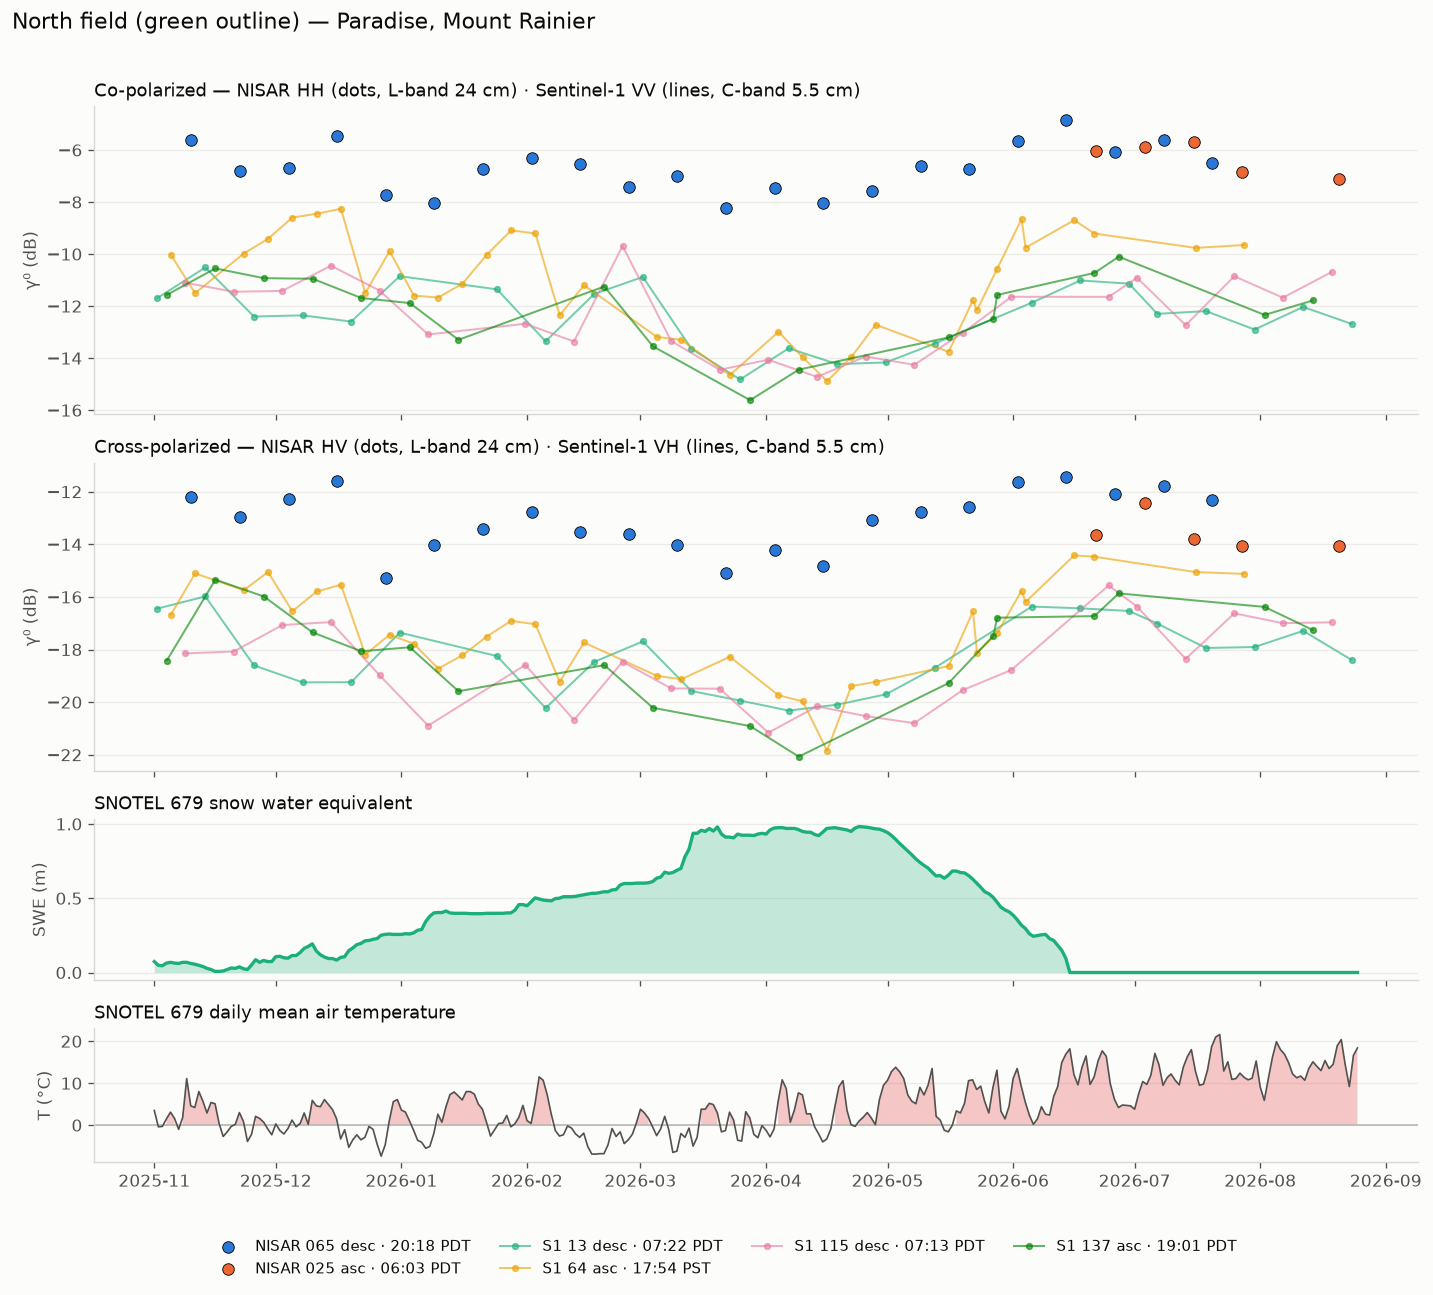

In [21]:
def series_figure(fieldname, colour):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10.5), sharex=True,
                             gridspec_kw={"height_ratios": [2.3, 2.3, 1.2, 1.0]})

    for row, (npol, spol, kind) in enumerate([("HH", "VV", "Co-polarized"),
                                              ("HV", "VH", "Cross-polarized")]):
        ax = axes[row]
        for i, (tkey, per_field) in enumerate(NISAR.items()):
            d = per_field[fieldname]
            ax.scatter(d.index, d[npol].values, color=SLOTS[i], s=48, zorder=3,
                       edgecolor="black", linewidth=0.5,
                       label=orbit_label(tkey[1], tkey[0], d.index, "NISAR"))
        for j, o in enumerate(S1_ORBITS):
            d = S1[o][fieldname]
            st, _ = S1_META[o]
            ax.plot(d.index, d[spol].values, color=SLOTS[(len(NISAR) + j) % len(SLOTS)],
                    lw=1.2, alpha=0.6, marker="o", ms=3.4, zorder=2,
                    label=orbit_label(o, st, d.index, "S1"))
        ax.set_ylabel("γ⁰ (dB)")
        ax.set_title(f"{kind} — NISAR {npol} (dots, L-band 24 cm) · "
                     f"Sentinel-1 {spol} (lines, C-band 5.5 cm)",
                     loc="left", color=INK)

    ax = axes[2]
    ax.fill_between(swe.index, 0, swe.values, color=CAT[2], alpha=0.25, linewidth=0)
    ax.plot(swe.index, swe.values, color=CAT[2], lw=2)
    ax.set_ylabel("SWE (m)")
    ax.set_title("SNOTEL 679 snow water equivalent", loc="left", color=INK)

    ax = axes[3]
    ax.axhline(0, color="#b9b8b3", lw=1)
    ax.plot(tavg.index, tavg.values, color=INK2, lw=1)
    ax.fill_between(tavg.index, 0, tavg.values, where=tavg.values > 0,
                    color="#e34948", alpha=0.30, linewidth=0)
    ax.set_ylabel("T (°C)")
    ax.set_title("SNOTEL 679 daily mean air temperature", loc="left", color=INK)

    for a in axes:
        a.grid(axis="y"); a.set_axisbelow(True)

    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.035),
               fontsize=9)
    fig.suptitle(f"{fieldname.capitalize()} field ({colour} outline) — Paradise, "
                 f"Mount Rainier", x=0.005, ha="left", fontsize=13, color=INK)
    fig.tight_layout(rect=(0, 0.03, 1, 0.97))
    return fig

series_figure("north", "green")
plt.show()

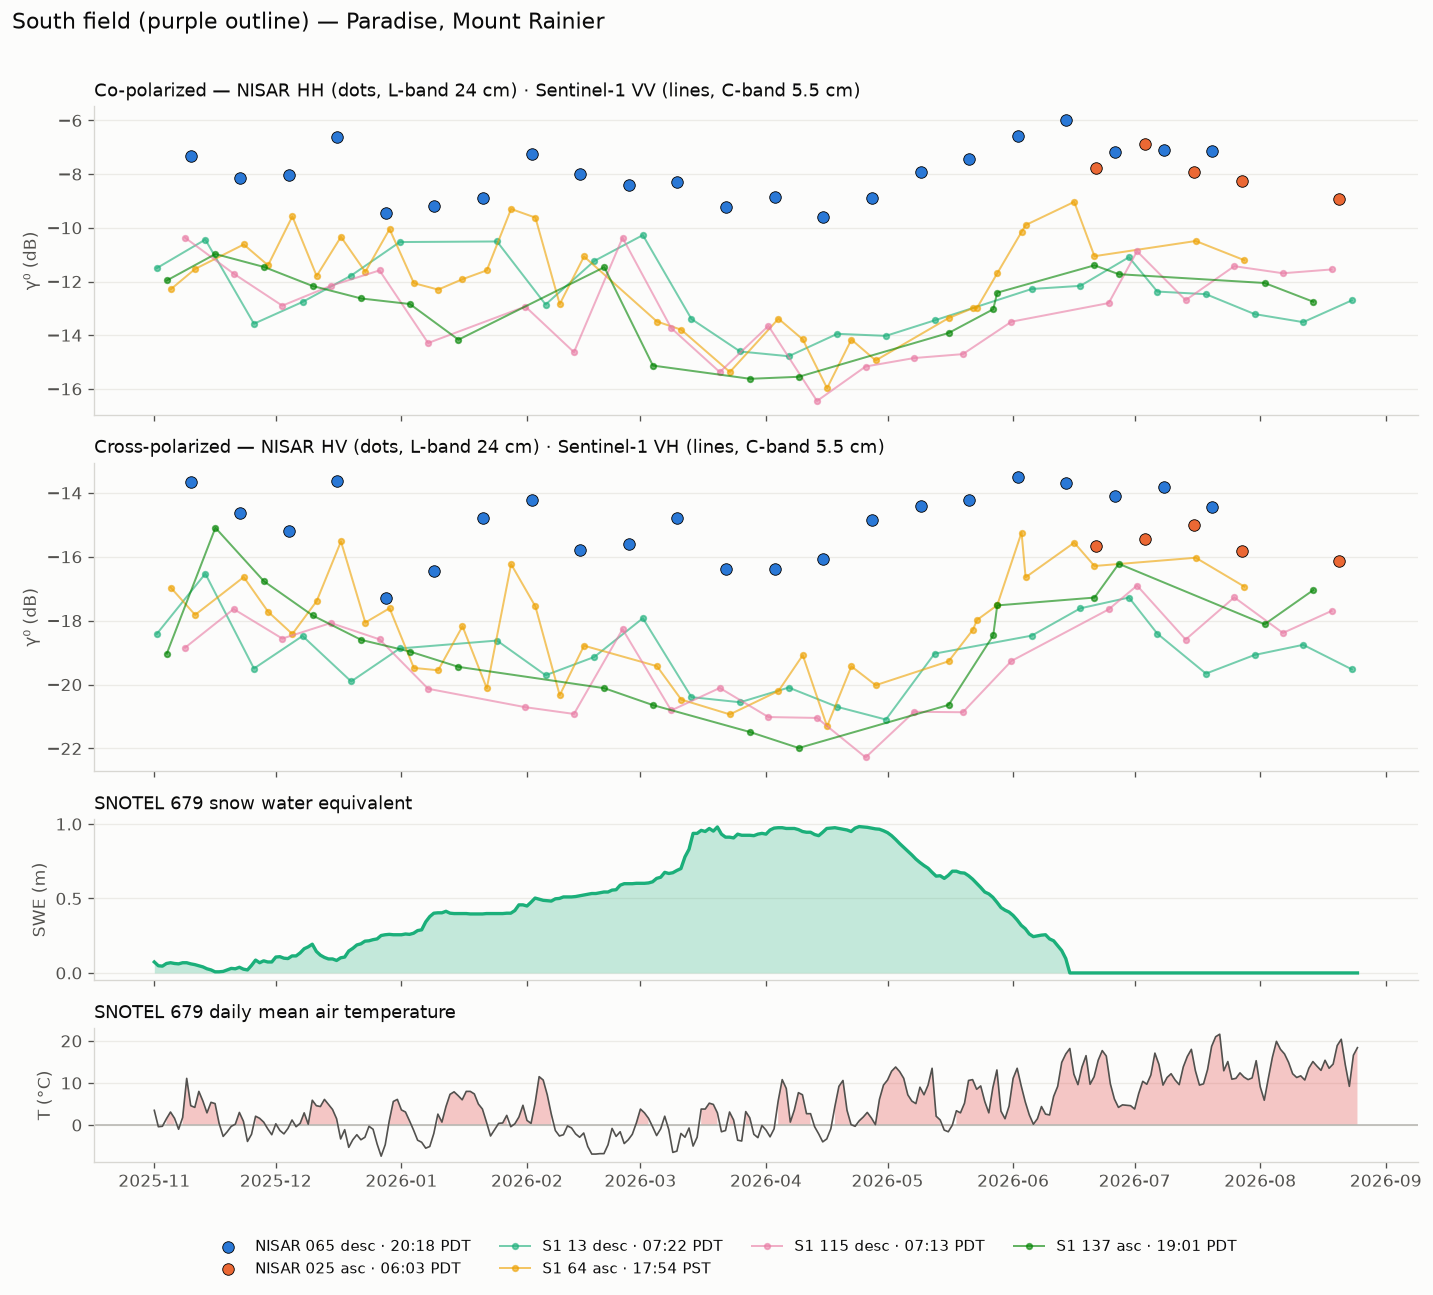

In [22]:
series_figure("south", "purple")
plt.show()

### 4.6 What the three records say together

In [23]:
melt_start = swe.idxmax()
snow_free = swe[(swe.index > melt_start) & (swe <= 0.001)].index[0]
print(f"SNOTEL: peak SWE {swe.max():.2f} m on {melt_start:%Y-%m-%d}, "
      f"snow-free {snow_free:%Y-%m-%d}\n")

for label, frame, cop, xpol in (("NISAR L-band", nisar, "HH", "HV"),
                                ("Sentinel-1 C-band", s1, "VV", "VH")):
    s = frame[("north", cop)]
    acc = s[s.index <= melt_start]
    melt = s[(s.index > melt_start) & (s.index <= snow_free)]
    bare = s[s.index > snow_free]
    print(f"{label} {cop} median γ⁰")
    print(f"   accumulation (to {melt_start:%b %d}) : {acc.median():6.2f} dB  (n={len(acc)})")
    print(f"   melt ({melt_start:%b %d}–{snow_free:%b %d})      : {melt.median():6.2f} dB  (n={len(melt)})")
    print(f"   snow-free (after {snow_free:%b %d})   : {bare.median():6.2f} dB  (n={len(bare)})")
    print(f"   melt minus snow-free            : {melt.median() - bare.median():+6.2f} dB\n")

SNOTEL: peak SWE 0.98 m on 2026-04-24, snow-free 2026-06-15

NISAR L-band HH median γ⁰
   accumulation (to Apr 24) :  -6.89 dB  (n=14)
   melt (Apr 24–Jun 15)      :  -6.62 dB  (n=5)
   snow-free (after Jun 15)   :  -6.06 dB  (n=3)
   melt minus snow-free            :  -0.55 dB

Sentinel-1 C-band VV median γ⁰
   accumulation (to Apr 24) : -11.35 dB  (n=24)
   melt (Apr 24–Jun 15)      : -11.77 dB  (n=7)
   snow-free (after Jun 15)   :  -9.43 dB  (n=4)
   melt minus snow-free            :  -2.34 dB



### 4.7 Against the ground truth

The season medians say something, but the sharper question is whether the radar tracks the
snowpack *continuously*. SNOTEL reports daily; interpolate it onto each acquisition date and
correlate.

In [24]:
def swe_at(idx):
    days = pd.DatetimeIndex(idx).normalize()
    return swe.reindex(swe.index.union(days)).interpolate().reindex(days).values

print(f"{'channel':10s} {'n':>3s} {'r vs SWE':>9s} {'range':>7s}   "
      f"{'minimum':>18s}   {'maximum':>18s}")
for label, ser in (("NISAR HH", nisar[("north", "HH")]),
                   ("NISAR HV", nisar[("north", "HV")]),
                   ("S1 VV", s1[("north", "VV")]),
                   ("S1 VH", s1[("north", "VH")])):
    w, v = swe_at(ser.index), ser.values
    m = np.isfinite(w) & np.isfinite(v)
    r = np.corrcoef(w[m], v[m])[0, 1]
    print(f"{label:10s} {m.sum():3d} {r:+9.2f} {ser.max()-ser.min():6.2f} dB   "
          f"{ser.min():6.2f} dB {ser.idxmin():%b %d}   {ser.max():6.2f} dB {ser.idxmax():%b %d}")
print(f"\npeak SWE {swe.max():.2f} m on {melt_start:%b %d}; snow-free {snow_free:%b %d}")

channel      n  r vs SWE   range              minimum              maximum
NISAR HH    22     -0.67   3.37 dB    -8.23 dB Mar 22    -4.86 dB Jun 14
NISAR HV    22     -0.63   3.86 dB   -15.29 dB Dec 28   -11.43 dB Jun 14
S1 VV       35     -0.83   6.63 dB   -14.89 dB Apr 16    -8.26 dB Dec 17
S1 VH       35     -0.86   7.43 dB   -21.85 dB Apr 16   -14.42 dB Jun 16

peak SWE 0.98 m on Apr 24; snow-free Jun 15


**Every channel anti-correlates with the snow pillow**: more water in the pack, less backscatter.
And the two radars disagree by exactly the amount wavelength predicts — Sentinel-1 at 5.5 cm
tracks SWE far more tightly than NISAR at 24 cm, over roughly twice the dynamic range. L-band
penetrates deeper and keeps more of the ground return, so it is the less sensitive snow
instrument of the two. Both minima land near peak SWE and both recover as the pack disappears.

That is the useful outcome. Not that any one series looks seasonal — a single series can look
seasonal for bad reasons — but that three independent records, two of them from satellites that
share nothing but a target, order themselves the way the physics says they should.

---
## 5. Zooming out

The same cube, used at the scale of the whole mountain rather than one field: six windows on an
elevation gradient from the summit to lowland forest. The lowest site is the control — mature
conifer forest at L-band is close to seasonally invariant, so if it moves as much as the snow
sites, the problem is in the processing chain rather than on the ground.

In [25]:
from pyproj import Transformer
to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{EPSG}", always_xy=True)

SITES = {"Summit": (46.8523, -121.7603, 4300), "Muir snowfield": (46.8450, -121.7350, 3000),
         "Emmons Glacier": (46.8700, -121.7000, 2000), "Paradise": (46.7860, -121.7350, 1650),
         "Forest SW": (46.7800, -121.9000, 800), "Forest W": (46.7600, -122.1200, 400)}
HALF = 32

x, y = cube.xCoordinates.values, cube.yCoordinates.values
lazy = {}
for name, (lat, lon, _) in SITES.items():
    ux, uy = to_utm.transform(lon, lat)
    iy, ix = int(np.argmin(np.abs(y - uy))), int(np.argmin(np.abs(x - ux)))
    sel = dict(yCoordinates=slice(iy - HALF, iy + HALF),
               xCoordinates=slice(ix - HALF, ix + HALF))
    lazy[name] = cube.HHHH.isel(**sel).median(("yCoordinates", "xCoordinates"))

t0 = time.time()
grad = retry(lambda: xr.Dataset(lazy).compute())
grad = 10 * np.log10(pd.DataFrame({k: grad[k].values for k in SITES},
                                  index=cube.time.to_index()))
print(f"6 sites x {len(grad)} dates in {time.time() - t0:.1f}s\n")
for name in sorted(SITES, key=lambda n: -SITES[n][2]):
    r = grad[name].max() - grad[name].min()
    print(f"{name:16s} {SITES[name][2]:5d} m   {r:5.2f} dB  {'█' * int(round(r * 4))}")

6 sites x 22 dates in 0.9s

Summit            4300 m    0.93 dB  ████
Muir snowfield    3000 m    3.36 dB  █████████████
Emmons Glacier    2000 m    4.28 dB  █████████████████
Paradise          1650 m    4.41 dB  ██████████████████
Forest SW          800 m    3.70 dB  ███████████████
Forest W           400 m    0.68 dB  ███


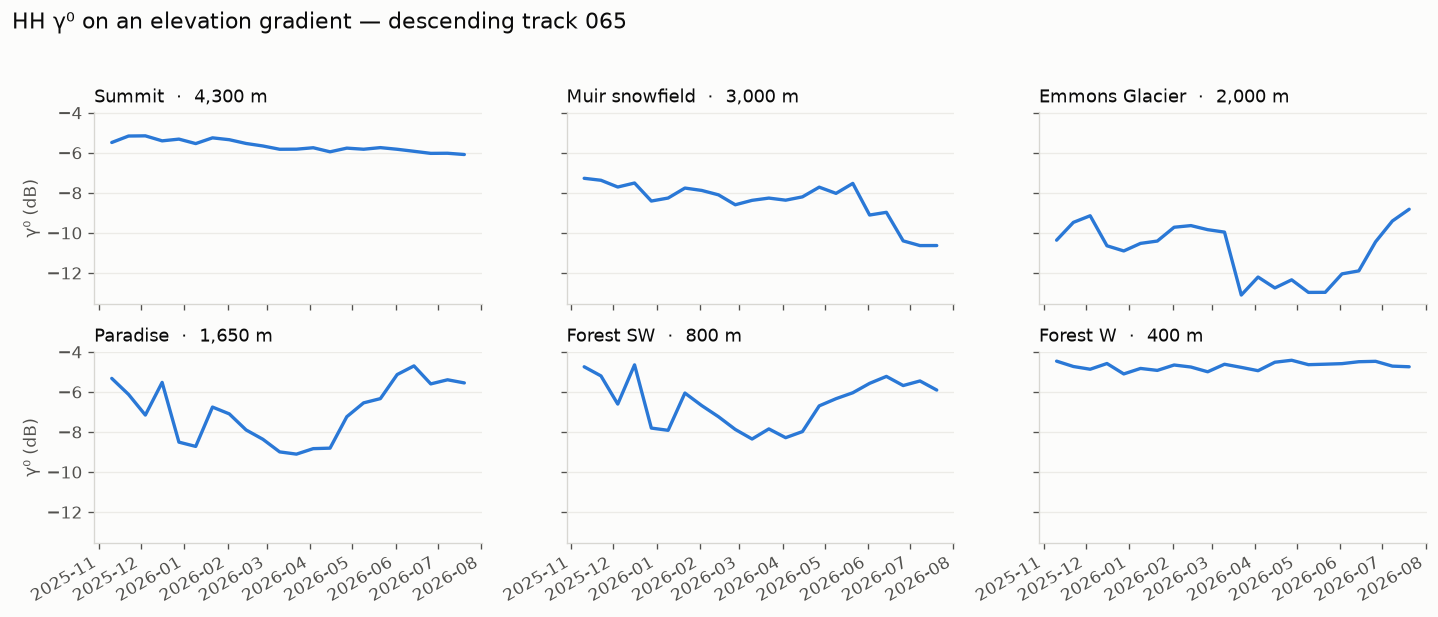

In [26]:
order = sorted(SITES, key=lambda n: -SITES[n][2])
fig, axes = plt.subplots(2, 3, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), order):
    ax.plot(grad.index, grad[name].values, color=CAT[0], lw=2, solid_capstyle="round")
    ax.set_title(f"{name}  ·  {SITES[name][2]:,} m", loc="left", color=INK)
    ax.grid(axis="y"); ax.set_axisbelow(True)
for ax in axes[:, 0]:
    ax.set_ylabel("γ⁰ (dB)")
for ax in axes[-1, :]:
    for lab in ax.get_xticklabels():
        lab.set_rotation(30); lab.set_ha("right")
fig.suptitle("HH γ⁰ on an elevation gradient — descending track 065",
             x=0.005, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### A wider look, and the difference between two dates

Grayscale for the magnitudes, as everywhere else. The difference between two dates is a *polarity*
— up or down — so it gets the diverging map instead. Everything is multilooked 5× first: a single
SAR pixel is a noisy estimate of γ⁰, and differencing two noisy estimates squares the problem.

C-band gets the same treatment on the same dates, from a single Sentinel-1 relative orbit so the
look geometry is held constant across the pair. Both rows are labelled with their orbit — the two
sensors see this mountain from different directions at different times of day, and a difference
image is meaningless without knowing which. The rows are *not* the same geometry: NISAR here is
descending and evening, Sentinel-1 orbit 64 is ascending and late afternoon, which is why the
bright and dark flanks swap sides between them.

Each difference panel is scaled to its own 98th percentile rather than a shared one. The
seasonal change is genuinely larger in C-band, and forcing both onto one scale would either
saturate C-band or flatten L-band.

two 20 km windows centred on the summit in 0.9s, multilooked 5x to (400, 400)


Data searched. Access the returned seach with the .search attribute.


Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.


Metadata retrieved. Access with the .metadata attribute.
Falsely low scenes and border noise removed from the data.
Added relative orbit number and orbit state as coordinates to the data.
Linear power units converted to dB. Convert back to linear power units using the .db_to_linear() method.


Data searched. Access the returned seach with the .search attribute.


Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Metadata retrieved. Access with the .metadata attribute.


Falsely low scenes and border noise removed from the data.
Added relative orbit number and orbit state as coordinates to the data.
Linear power units converted to dB. Convert back to linear power units using the .db_to_linear() method.


Sentinel-1 orbit 64 (ascending): 2026-03-23, 2026-07-16


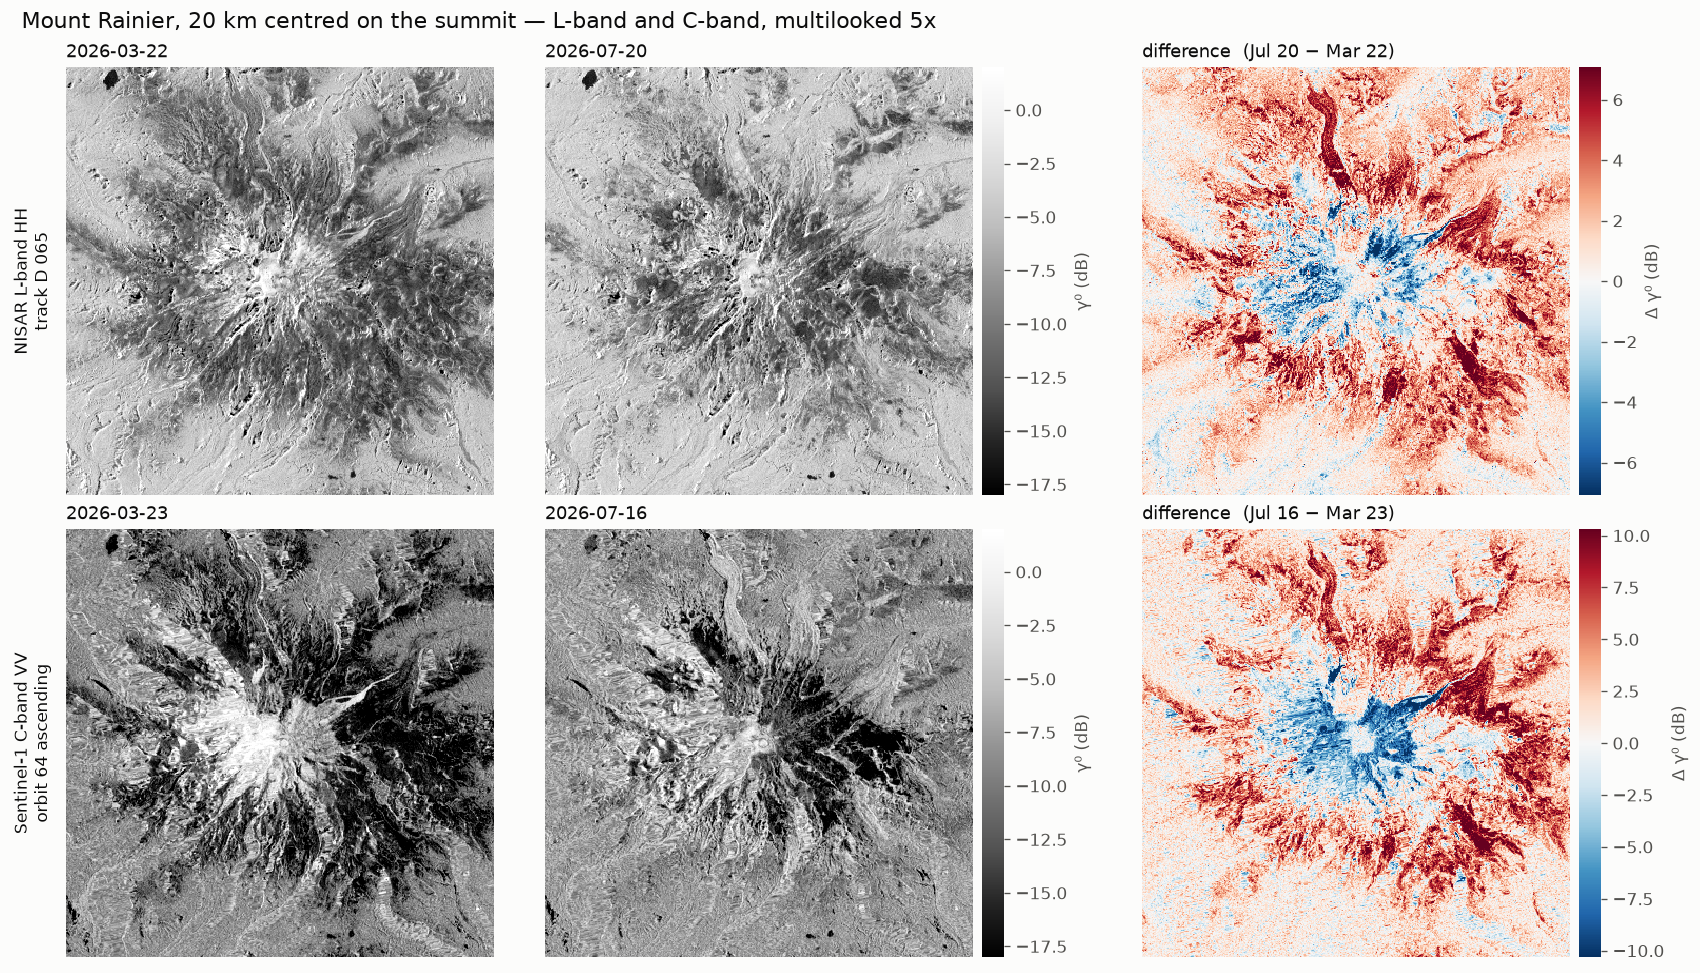

L-band: NISAR track D 065, 065 desc · 20:18 PDT
C-band: Sentinel-1 orbit 64 ascending, 64 asc · 17:54 PST


In [27]:
def multilook(a, k=5):
    ny, nx = (s // k * k for s in a.shape)
    return np.nanmean(a[:ny, :nx].reshape(ny // k, k, nx // k, k), axis=(1, 3))

sx, sy = to_utm.transform(SUMMIT[0], SUMMIT[1])
iy0, ix0 = int(np.argmin(np.abs(y - sy))), int(np.argmin(np.abs(x - sx)))
W = 1000
sel = dict(yCoordinates=slice(iy0 - W, iy0 + W), xCoordinates=slice(ix0 - W, ix0 + W))

lowest, highest = grad["Emmons Glacier"].idxmin(), grad["Emmons Glacier"].idxmax()
t0 = time.time()
scenes = {d: multilook(10 * np.log10(
              retry(lambda d=d: cube.HHHH.sel(time=d).isel(**sel).values)))
          for d in (lowest, highest)}
print(f"two 20 km windows centred on the summit in {time.time() - t0:.1f}s, "
      f"multilooked 5x to {list(scenes.values())[0].shape}")

# --- the same two dates in C-band, from one Sentinel-1 orbit ---------------
wide = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries.from_xy(*[[v] for v in to_utm.transform(*SUMMIT)],
                                   crs=EPSG).buffer(W * 10), crs=EPSG).to_crs(4326)

def s1_near(when, days=6):
    lo = (when - pd.Timedelta(days=days)).strftime("%Y-%m-%d")
    hi = (when + pd.Timedelta(days=days)).strftime("%Y-%m-%d")
    return easysnowdata.remote_sensing.Sentinel1(
        bbox_input=wide, start_date=lo, end_date=hi).data

w_lo, w_hi = s1_near(lowest), s1_near(highest)
common = (set(np.asarray(w_lo["sat:relative_orbit"].values).astype(int).tolist()) &
          set(np.asarray(w_hi["sat:relative_orbit"].values).astype(int).tolist()))
S1_ORB = ORBIT if ORBIT in common else sorted(common)[0]

# On a lazy dataset `sat:orbit_state` is an Arrow-backed string array that
# xarray cannot index at all, so read it out of the raw arrays and drop the
# coordinate before any selection touches it.
orb_of = lambda ds: np.asarray(ds["sat:relative_orbit"].values).astype(int)
state_of = lambda ds: np.asarray(ds["sat:orbit_state"].values).astype(str)
c_state = str(state_of(w_lo)[orb_of(w_lo) == S1_ORB][0])

def pick(ds, when):
    ds = ds.drop_vars([v for v in ("sat:orbit_state",) if v in ds.coords])
    sub = ds.sel(time=ds["sat:relative_orbit"] == S1_ORB)
    i = int(np.argmin(np.abs(pd.DatetimeIndex(sub.time.values) - when)))
    return sub.isel(time=i)

c_lo, c_hi = pick(w_lo, lowest), pick(w_hi, highest)
c_scenes = {pd.Timestamp(c.time.values): multilook(c.vv.values) for c in (c_lo, c_hi)}
print(f"Sentinel-1 orbit {S1_ORB} ({c_state}): "
      f"{', '.join(f'{d:%Y-%m-%d}' for d in c_scenes)}")

# --- two rows: L-band and C-band, magnitudes plus the difference ------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8.0), constrained_layout=True)
ROWLAB = [f"NISAR L-band HH\ntrack {key[0]} {key[1]}",
          f"Sentinel-1 C-band VV\norbit {S1_ORB} {c_state}"]

for r, (row_scenes, lab) in enumerate(((scenes, ROWLAB[0]), (c_scenes, ROWLAB[1]))):
    ds = list(row_scenes)
    for cix, d in enumerate(ds):
        im_m = axes[r, cix].imshow(row_scenes[d], cmap=SAR_CMAP, vmin=SAR_VMIN,
                                   vmax=SAR_VMAX, interpolation="nearest")
        axes[r, cix].set_title(f"{d:%Y-%m-%d}", loc="left", color=INK)
    dif = row_scenes[ds[1]] - row_scenes[ds[0]]
    m = np.nanpercentile(np.abs(dif[np.isfinite(dif)]), 98)
    im_d = axes[r, 2].imshow(dif, cmap="RdBu_r", vmin=-m, vmax=m,
                             interpolation="nearest")
    axes[r, 2].set_title(f"difference  ({ds[1]:%b %d} − {ds[0]:%b %d})",
                         loc="left", color=INK)
    cb = fig.colorbar(im_d, ax=axes[r, 2], fraction=0.046, pad=0.02)
    cb.set_label("Δ γ⁰ (dB)", color=INK2); cb.outline.set_visible(False)
    cbm = fig.colorbar(im_m, ax=axes[r, :2].tolist(), fraction=0.030, pad=0.01)
    cbm.set_label("γ⁰ (dB)", color=INK2); cbm.outline.set_visible(False)
    axes[r, 0].set_ylabel(lab, fontsize=10, color=INK, labelpad=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle("Mount Rainier, 20 km centred on the summit — L-band and C-band, "
             "multilooked 5x", x=0.005, ha="left", fontsize=13, color=INK)
plt.show()

print(f"L-band: NISAR track {key[0]} {key[1]}, "
      f"{orbit_label(key[1], key[0], cube.time.values, '')}".replace("  ", " "))
print(f"C-band: Sentinel-1 orbit {S1_ORB} {c_state}, "
      f"{orbit_label(S1_ORB, c_state, S1_META[S1_ORB][1], '')}".replace("  ", " "))

---
## 6. Maintain

A new acquisition is published. `nv.append_new` reads the times already in the cube, indexes only
what is missing, checks it lands on the same grid, and appends.

In [28]:
new_items = [(s, u) for s, u, _ in members]
t0 = time.time()
snap, added = nv.append_new(repo, new_items, drop_variables=drop)
print(f"append: {time.time() - t0:.1f}s -> {len(added)} new "
      f"({', '.join(d.strftime('%Y-%m-%d') for d in added)})")

snap2, added2 = nv.append_new(repo, new_items, drop_variables=drop)
print(f"re-run: {snap2} -> {len(added2)} added (idempotent)\n")

size = lambda: sum(f.stat().st_size for f in REPO_PATH.rglob("*") if f.is_file()) / 1e6
before = size()
expired, _ = nv.compact(repo)
cube = nv.open_cube(repo)
print(f"compaction: {len(expired)} snapshots expired, {before:.1f} MB -> {size():.1f} MB")
print(f"cube now spans {len(cube.time)} acquisitions, "
      f"{cube.time.values[0].astype('datetime64[D]')} .. "
      f"{cube.time.values[-1].astype('datetime64[D]')}")

append: 2.7s -> 1 new (2026-08-13)
re-run: None -> 0 added (idempotent)

compaction: 1 snapshots expired, 8.4 MB -> 4.9 MB
cube now spans 23 acquisitions, 2025-11-10 .. 2026-08-13


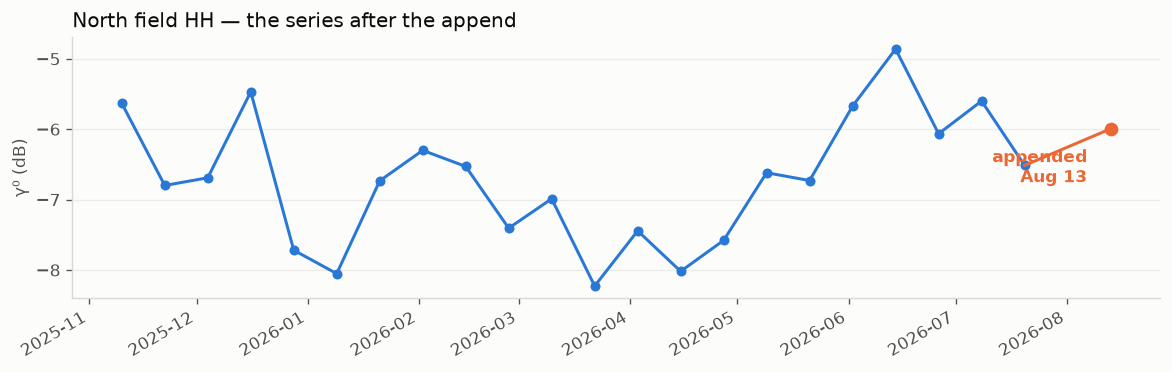

In [29]:
hh_after = retry(lambda: to_db(chip(cube.HHHH, field_gdf)).compute())
after = field_median(hh_after, north_gdf)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(after.index[:-1], after.values[:-1], color=CAT[0], lw=1.8,
        marker="o", ms=5, solid_capstyle="round")
ax.plot(after.index[-2:], after.values[-2:], color=CAT[1], lw=1.8)
ax.scatter(after.index[-1:], after.values[-1:], color=CAT[1], s=52, zorder=3)
ax.annotate(f"appended\n{after.index[-1]:%b %d}", xy=(after.index[-1], after.values[-1]),
            xytext=(-14, -32), textcoords="offset points", color=CAT[1],
            fontweight="bold", ha="right")
ax.grid(axis="y"); ax.set_axisbelow(True); ax.set_ylabel("γ⁰ (dB)")
ax.set_title("North field HH — the series after the append", loc="left",
             fontsize=12, color=INK)
for lab in ax.get_xticklabels():
    lab.set_rotation(30); lab.set_ha("right")
fig.tight_layout()
plt.show()

---
## What this demonstrates, and what it does not

**The round trip closes.** Virtual references go into an Icechunk store; real pixels come back out,
byte-identical to the source HDF5 (§2). Nothing was copied to make that true — every read is a
range request against an original `.h5` in the ASF bucket. The index for a multi-terabyte,
ten-month cube is a few megabytes and reopens in a fraction of a second.

**That changes what the analysis code looks like.** The reference notebook this one mirrors opens
28 HDF5 files over HTTPS, every session, before it can do anything. Here the equivalent work is
`nv.open_cube(repo)` followed by ordinary xarray. That is the entire deliverable; the science
below is how we check it survived the trip.

**The sensors agree, and they disagree in the way wavelength predicts.** Over the same field every
radar channel anti-correlates with the snow pillow — more water in the pack, less backscatter —
and Sentinel-1 at 5.5 cm tracks SWE substantially more tightly than NISAR at 24 cm, over roughly
twice the dynamic range. That ordering is the physical expectation, not a surprise: L-band
penetrates further and keeps more of the ground return, which makes it the less sensitive snow
instrument of the two. Both minima land near peak SWE and both recover as the pack disappears in
mid-June; the Sentinel-2 chips confirm snow on the ground on the dates the radars say there is.

Read the melt window on its own and L-band looks almost flat — the melt-versus-snow-free step is a
few tenths of a decibel, against a couple of decibels for C-band. The continuous comparison
against SWE is the more honest instrument here, and it is only available because the cube made a
22-date series cheap enough to compute in a second.

**What would be needed to call it science.** One descending track and one look geometry for NISAR;
a single Sentinel-1 relative orbit chosen to hold geometry constant, which throws away most of the
C-band record; two hand-drawn fields; no DEM, so no incidence-angle or layover treatment; and
**provisional NISAR products**, which carry no guarantee of radiometric stability across the
record. SNOTEL measures a point, the radar measures a few hundred metres of slope around it. This
is a plausible melt signal cross-checked three ways, not a melt-timing retrieval.

**Two failures worth keeping.** Granules sharing a track and frame landed on two different output
grids (§1.4), and an early version of this analysis reused pixel indices across both — producing a
clean 6 dB "seasonal" drop at every site, including the forest control, because five granules'
indices pointed 250 km away. Nothing errored and the numbers looked plausible. Group by the
coordinate arrays, and keep a site in the analysis that is supposed to stay still.